In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import io
import astropy.io.fits
import src.downloadCutout as downloadCutout
import src.downloadPsf as downloadPsf

from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph
import warnings
from tqdm import tqdm
from joblib import Parallel, delayed
np.random.seed(42)
plt.rcParams['font.size'] = 16

In [2]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0428_all_test.fits')
dps_df = dps_df[['TARGETID', 'LOGM', 'LOGSFR_2COMP', 'Z', 'DV_R', 'DV_L', 'SIGMA_R', 'SIGMA_L', 'Halpha_SNR', 'P_VALUE']]
dps_df['delta_DV'] = dps_df['DV_R'] - dps_df['DV_L']
dps_df['LOGsSFR'] = dps_df['LOGSFR_2COMP'] - dps_df['LOGM']
dps_df = dps_df[((~dps_df['LOGSFR_2COMP'].isna())|(dps_df['LOGSFR_2COMP']!=np.inf)) & (dps_df['LOGM']!=0) & (dps_df['Halpha_SNR']>0)]
morph_df = pd.read_csv('./catalogs/morph_dps.csv')

In [3]:
match_df = pd.merge(dps_df, morph_df, on=['TARGETID'], how='inner')
match_df['S(Gini, M20)'] = 0.139*match_df['M20'] + 0.990*match_df['Gini'] -0.327
match_df['F(Gini, M20)'] = -0.693*match_df['M20'] + 4.95*match_df['Gini'] -3.96
match_df.head(10)

,TARGETID,LOGM,LOGSFR_2COMP,Z,DV_R,DV_L,SIGMA_R,SIGMA_L,Halpha_SNR,P_VALUE,...,Sersic,M20,Gini,Concentration,Asymmetry,Smoothness,Shape_Asymmetry,Sersic_Ellipticity,"S(Gini, M20)","F(Gini, M20)"
0,39627739380061198,9.514435,0.235638,0.103277,87.714844,-73.869621,38.259602,50.303757,40.988579,1.110223e-16,...,1.597320,-1.726735,0.492137,2.702611,0.042496,0.052776,0.257943,0.394958,-0.079801,-0.327297
1,39627739396834832,9.580146,0.179014,0.166120,31.734863,-64.955193,56.488110,19.845049,23.862007,6.052531e-06,...,0.955405,-1.695766,0.469586,2.517247,0.020117,0.080430,0.056859,0.449368,-0.097821,-0.460382
2,39627739409419280,9.655142,0.119085,0.103501,43.981243,-58.595638,36.821556,38.674587,76.740387,1.110223e-16,...,1.710541,-1.603290,0.513229,2.721388,0.114662,0.077228,0.191320,0.374514,-0.041761,-0.308436
3,39627739409422333,10.146265,-0.365264,0.171386,43.015930,-94.129112,76.790909,31.321650,13.143264,1.136587e-05,...,2.010066,-1.852070,0.775985,2.949668,0.070079,-0.093419,0.000000,0.571644,0.183787,1.164608
4,39627739413613782,10.506872,-0.468153,0.176748,42.523750,-56.177319,47.667694,91.832672,14.679337,7.189499e-03,...,0.902883,-1.785477,0.450664,2.843677,0.066137,0.006692,0.159105,0.662955,-0.129023,-0.491875
5,39627739413615191,9.512184,-0.537902,0.176551,36.244694,-50.597248,34.316742,28.626219,23.790586,2.578916e-04,...,1.552655,-1.596679,0.558385,2.951425,0.051988,0.020485,0.387765,0.104368,0.003863,-0.089497
6,39627739426199525,10.451921,-0.872017,0.228582,77.765701,-88.532112,43.255760,57.842258,19.097990,9.064527e-12,...,1.900065,-1.870128,0.512001,2.961896,0.074996,0.003511,0.150945,0.388163,-0.080066,-0.129595
7,39627739430391569,9.886106,0.270901,0.248209,19.449024,-28.952538,57.045502,0.001000,49.277691,1.110223e-16,...,0.711342,-1.627530,0.447051,2.320461,0.085604,0.039973,0.215423,0.033265,-0.110646,-0.619219
8,39627739438781550,9.658495,0.509044,0.154892,16.059393,-30.879667,75.646400,18.842087,110.097221,1.110223e-16,...,0.599844,-1.575094,0.465870,2.266898,0.149239,0.041354,0.000000,0.364036,-0.084726,-0.562402
9,39627739442971043,10.215080,0.030970,0.151920,78.943420,-36.568565,42.476246,90.975922,26.797224,3.330669e-16,...,0.657632,-1.632033,0.440229,2.532004,0.075927,0.017125,0.670236,0.557320,-0.118026,-0.649869


In [4]:
match_df.columns

Index(['TARGETID', 'LOGM', 'LOGSFR_2COMP', 'Z', 'DV_R', 'DV_L', 'SIGMA_R',
       'SIGMA_L', 'Halpha_SNR', 'P_VALUE', 'delta_DV', 'LOGsSFR', 'RA', 'DEC',
       'Sersic', 'M20', 'Gini', 'Concentration', 'Asymmetry', 'Smoothness',
       'Shape_Asymmetry', 'Sersic_Ellipticity', 'S(Gini, M20)',
       'F(Gini, M20)'],
      dtype='object')

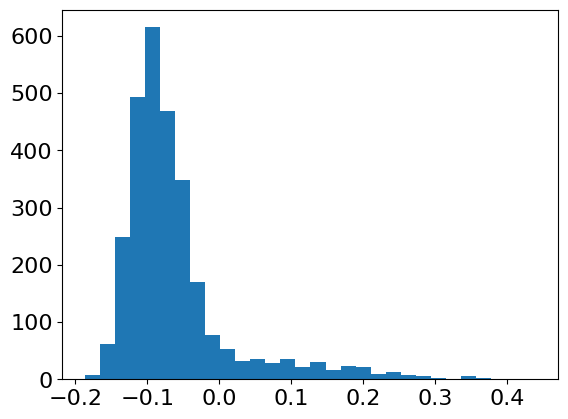

In [5]:
plt.hist(match_df['S(Gini, M20)'], bins=30)
plt.show()

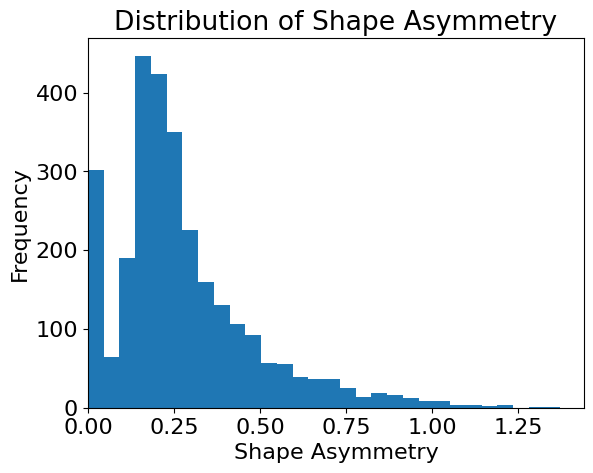

In [6]:
plt.hist(match_df['Shape_Asymmetry'], bins=30)
plt.xlim(left=0)
plt.xlabel('Shape Asymmetry')
plt.ylabel('Frequency')
plt.title('Distribution of Shape Asymmetry')
plt.show()

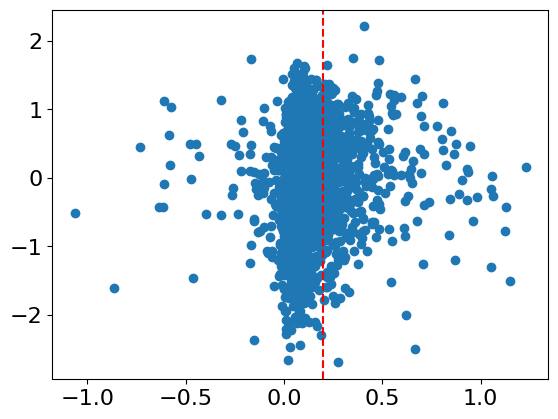

In [7]:
plt.scatter(match_df['Asymmetry'], match_df['LOGSFR_2COMP'])
plt.axvline(x=0.2, color='r', linestyle='--')
plt.show()

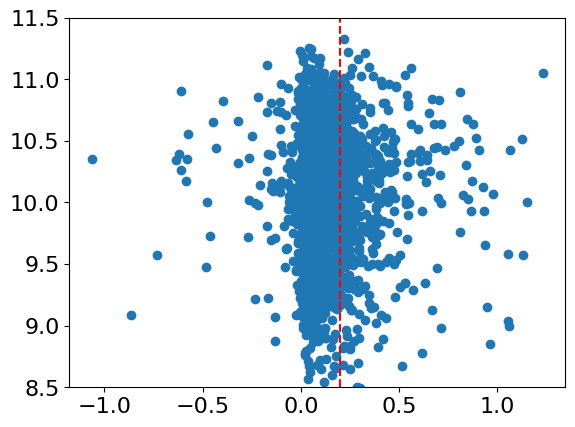

In [8]:
plt.scatter(match_df['Asymmetry'], match_df['LOGM'])
plt.axvline(x=0.2, color='r', linestyle='--')
plt.ylim(8.5, 11.5)
plt.show()

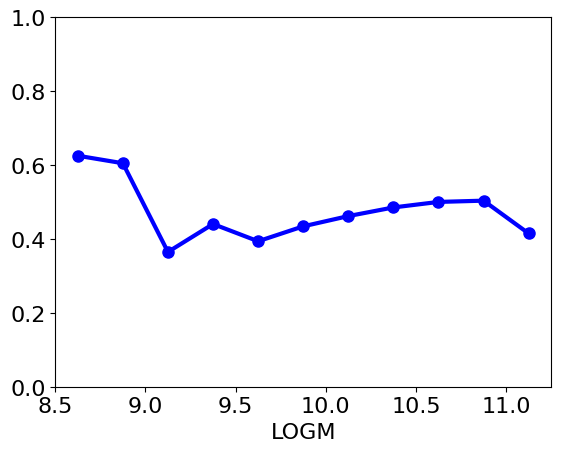

In [9]:
logm_bins_bound = np.arange(8.5, 11.5, 0.25)
s_rates = []
for i in range(len(logm_bins_bound) - 1):
    subset = match_df[(match_df['LOGM'] >= logm_bins_bound[i]) & (match_df['LOGM'] < logm_bins_bound[i+1])]
    s_rate = len(subset[(subset['Asymmetry']>0.1)])/len(subset)
    s_rates.append(s_rate)
plt.plot(logm_bins_bound[:-1]+0.125, s_rates, marker='o', linewidth=3, color='blue', markersize=8)
plt.ylim(0, 1)
plt.xlabel('LOGM')
plt.show()

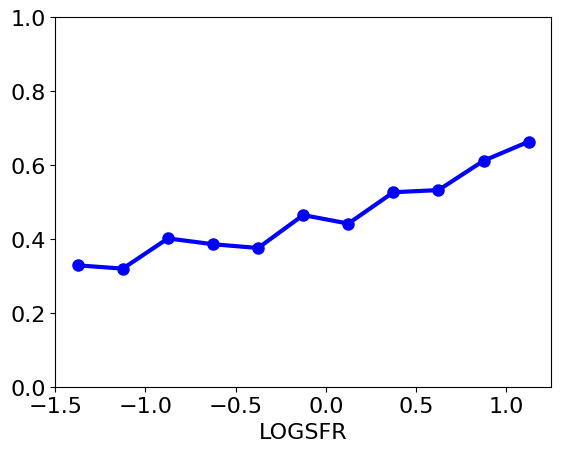

In [30]:
logsfr_bins_bound = np.arange(-1.5, 1.5, 0.25)
asymmetry_rates = []
for i in range(len(logsfr_bins_bound) - 1):
    subset = match_df[(match_df['LOGSFR_2COMP'] >= logsfr_bins_bound[i]) & (match_df['LOGSFR_2COMP'] < logsfr_bins_bound[i+1])]
    dp_rate = len(subset[(subset['Asymmetry']>0.1)])/len(subset)
    asymmetry_rates.append(dp_rate)
plt.plot(logsfr_bins_bound[:-1]+0.125, asymmetry_rates, marker='o', linewidth=3, color='blue', markersize=8)
plt.ylim(0, 1)
plt.xlabel('LOGSFR')
plt.show()

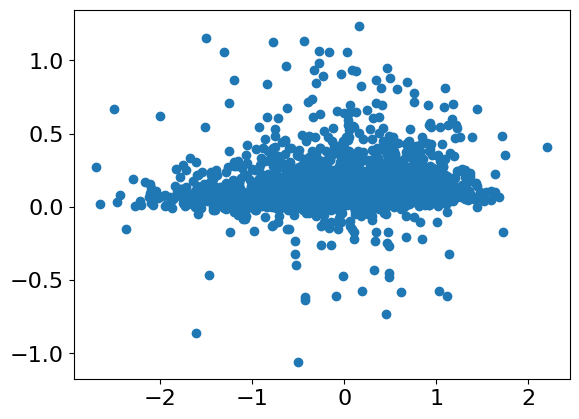

In [12]:
plt.scatter(match_df['LOGSFR_2COMP'], match_df['Asymmetry'])
plt.show()

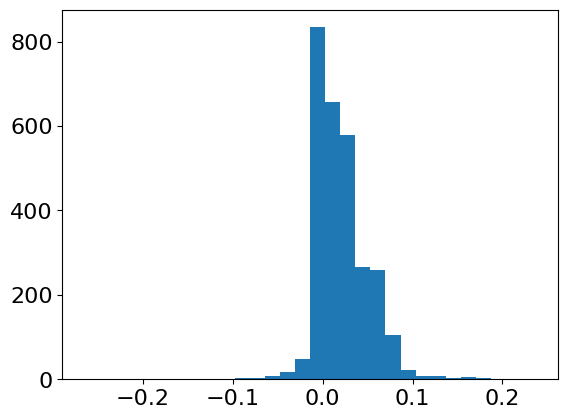

In [14]:
plt.hist(match_df['Smoothness'], bins=30)
plt.show()

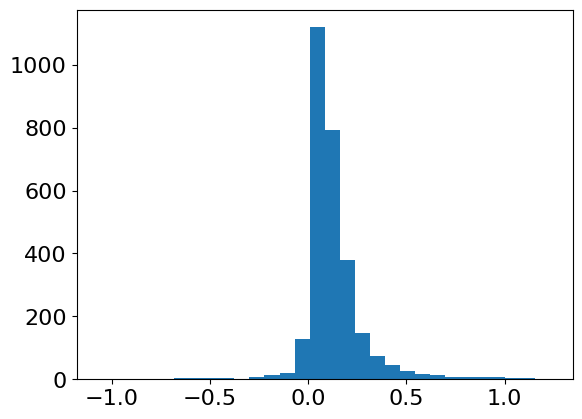

In [15]:
plt.hist(match_df['Asymmetry'], bins=30)
plt.show()

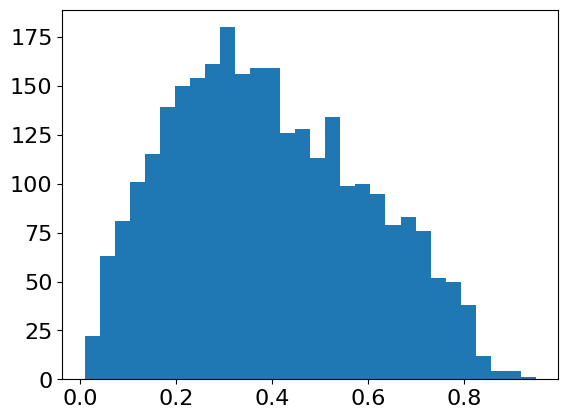

In [16]:
plt.hist(match_df['Sersic_Ellipticity'], bins=30)
plt.show()

In [17]:
# plt.scatter(match_df['Sersic_Ellipticity'], match_df['DV_R']-match_df['DV_L'], s=10)
# # plt.ylim(bottom=30)
# plt.show()

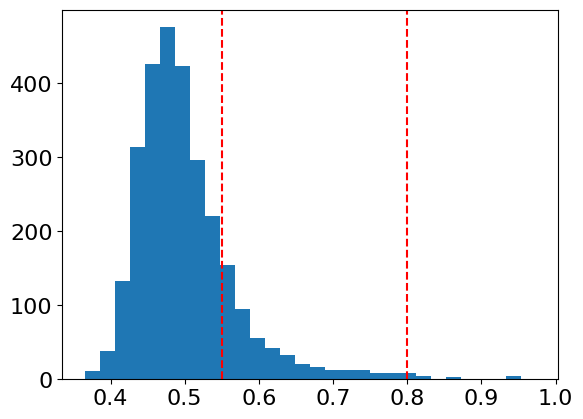

In [18]:
plt.hist(match_df['Gini'], bins=30)
plt.axvline(0.55, color='r', linestyle='--')
plt.axvline(0.8, color='r', linestyle='--')
plt.show()

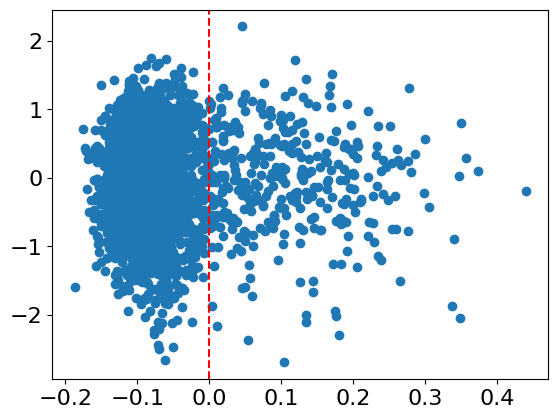

In [19]:
plt.scatter(match_df['S(Gini, M20)'], match_df['LOGSFR_2COMP'])
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

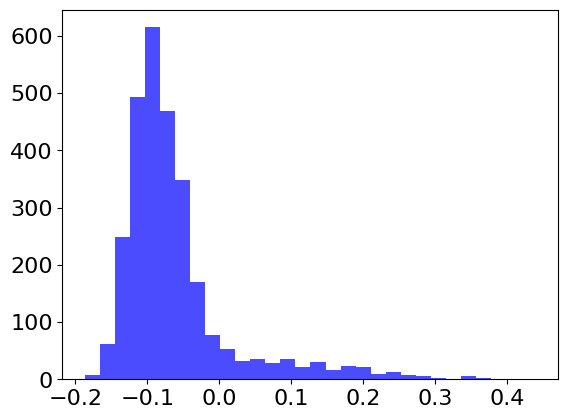

In [20]:
plt.hist(match_df['S(Gini, M20)'], bins=30, color='blue', alpha=0.7)
plt.show()

In [21]:
match_df.sort_values('Asymmetry', ascending=False).head(50)

,TARGETID,LOGM,LOGSFR_2COMP,Z,DV_R,DV_L,SIGMA_R,SIGMA_L,Halpha_SNR,P_VALUE,...,Sersic,M20,Gini,Concentration,Asymmetry,Smoothness,Shape_Asymmetry,Sersic_Ellipticity,"S(Gini, M20)","F(Gini, M20)"
712,39627763631524399,11.050571,0.165194,0.382302,1.444893e+02,-9.790543e+01,43.185371,215.041962,16.123039,1.110223e-16,...,0.139610,-1.282424,0.757777,1.028294,1.231043,0.130892,0.874483,0.780569,0.244943,0.679718
467,39627752218824904,10.003444,-1.503262,0.100091,2.816728e+01,-1.636817e+01,34.819267,11.331920,13.446754,3.280950e-02,...,0.209515,-0.894546,0.723440,1.281357,1.150680,0.159737,0.534722,0.750537,0.264863,0.240948
1896,39627794371577192,9.577500,-0.432132,0.062920,3.270490e+01,-4.705456e+01,58.707981,16.888805,32.510811,1.647571e-13,...,0.010000,-0.582209,0.719948,0.906580,1.131617,0.110707,0.713233,0.534083,0.304821,0.007212
2329,39627806585394111,10.512891,-0.776458,0.131661,3.254287e+01,-5.253892e+01,59.378563,0.001012,12.247268,8.678348e-04,...,0.010000,-0.548611,0.686258,0.926475,1.125795,0.151678,0.788634,0.623658,0.276139,-0.182835
2185,39627806014964390,10.429215,-0.269025,0.132385,7.396101e+01,-9.145480e+01,66.054901,38.115242,29.694288,1.110223e-16,...,0.010000,-0.723129,0.692949,0.802929,1.064773,0.139100,0.561827,0.715553,0.258504,-0.028775
1783,39627793876653564,8.995567,0.033672,0.106078,3.238395e+00,-1.139325e+01,19.751143,75.743530,66.326393,2.653433e-14,...,4.357900,-0.937152,0.812872,3.400650,1.059450,0.001181,0.777379,0.552477,0.347479,0.713163
2511,39627812595830564,9.585739,-0.160300,0.222185,4.197871e+00,-8.856456e+00,54.950924,143.076904,32.672211,2.979172e-12,...,0.010000,-2.030226,0.818007,0.762943,1.055315,0.194951,0.705623,0.818074,0.200626,1.496083
2247,39627806258236557,9.040211,-1.305702,0.047424,2.185858e+01,-1.524346e+01,0.048129,19.403944,27.412848,2.590318e-02,...,2.058651,-0.727478,0.639274,1.633542,1.054768,0.094063,1.050963,0.622394,0.204762,-0.291449
751,39627763774133573,10.067060,-0.276817,0.089443,1.016055e-12,-7.086217e-01,0.001003,73.387650,25.261091,8.990800e-06,...,0.161699,-0.834270,0.620358,1.702098,0.979691,0.089832,0.992934,0.687221,0.171190,-0.311081
2606,39627818232973737,8.848487,-0.633140,0.096262,1.517478e+01,-9.241183e+00,0.001000,45.422611,48.791424,1.352201e-08,...,0.010000,-1.158051,0.670680,1.231805,0.963307,0.108988,0.706606,0.854361,0.176004,0.162396
